# Tomatbladsklassificering med Transfer Learning

**Del av gruppprojektet "Plant Disease Detection" — min (Spirits) analys**

Det här är min del av gruppens mikroprojekt om Transfer Learning. Vi (jag, Emmy och Mahtab)
undersöker om en förtränad bildmodell kan läras om till att känna igen sjuka tomatblad,
istället för att bygga och träna en modell helt från grunden.

**Caset:** En tomatodlare vill kunna ta ett foto på ett blad och snabbt få en indikation på om
bladet är friskt eller visar tecken på *Early Blight* (tidig bladmögel) eller *Late Blight*
(sen bladmögel), som ett första steg mot snabbare upptäckt och mindre skördeförlust.

**Dataset:** [PlantVillage](https://www.kaggle.com/datasets/mohitsingh1804/plantvillage) från
Kaggle. Vi använder tre klasser från samma växtart (tomat), vilket gör klassificeringen mer
meningsfull — modellen måste lära sig sjukdomsrelaterade mönster snarare än att bara skilja på
olika växtarter.

**Vad jag gör i den här notebooken:**
1. Utforskar datasetet (klassfördelning, exempelbilder)
2. Bygger en dataladdnings-pipeline
3. Bygger **Modell 1**: MobileNetV2 med helt fryst basmodell + egna klassificeringslager
4. Bygger **Modell 2**: samma modell, men finjusterad (sista lagren i basmodellen upplåsta)
5. Jämför de två modellerna med confusion matrix och nyckeltal
6. Tittar på konkreta exempel på rätt och fel prediktioner
7. **Bonus:** en fördjupning i hur self-attention/attention fungerar i transformermodeller
   som BERT — samma koncept som i föreläsningen, fast med en riktig modell och riktig data

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input

from sklearn.metrics import confusion_matrix, classification_report

# Reproducerbarhet: samma slumptal varje gång jag kör om notebooken
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

sns.set_theme(style="whitegrid")

# Mapp där jag sparar grafer som PNG, så jag enkelt kan dra in dem i presentationen
FIG_DIR = Path("../reports/figures")
FIG_DIR.mkdir(parents=True, exist_ok=True)

def save_fig(name):
    plt.savefig(FIG_DIR / f"spirit_{name}.png", dpi=150, bbox_inches="tight")

print("TensorFlow-version:", tf.__version__)

TensorFlow-version: 2.21.0


**Vad gör det här blocket?**

Här samlar jag alla bibliotek jag använder genom hela notebooken på ett ställe, istället för
att importera dem utspritt. `tensorflow.keras` är det jag bygger och tränar modellerna med,
`sklearn.metrics` använder jag för att utvärdera modellerna (confusion matrix och
klassificeringsrapport), och `matplotlib`/`seaborn` för alla grafer.

Jag sätter en **seed** (42) på alla ställen som använder slump (Python, NumPy, TensorFlow).
Det gör att t.ex. datauppdelning, viktinitiering och dataaugmentering blir identiska varje
gång jag kör om notebooken från början — annars hade jag fått lite olika resultat varje körning,
vilket gör det svårare att jämföra modeller rättvist.

Jag skapar också en `reports/figures`-mapp och en liten hjälpfunktion `save_fig()` som sparar
varje viktig graf som en egen PNG-fil — det gör att jag enkelt kan plocka ut just de bilderna
jag vill visa i presentationen, utan att behöva ta skärmdumpar av notebooken.

In [2]:
DATA_DIR = Path("../data/raw/plantvillage/PlantVillage")
TRAIN_DIR = DATA_DIR / "train"
VAL_DIR = DATA_DIR / "val"

# Ordningen här bestämmer vilket heltal (0, 1, 2) varje klass får internt i modellen.
CLASS_NAMES = ["Tomato___healthy", "Tomato___Early_blight", "Tomato___Late_blight"]
LABELS = {
    "Tomato___healthy": "Healthy",
    "Tomato___Early_blight": "Early Blight",
    "Tomato___Late_blight": "Late Blight",
}
IMAGE_EXTS = {".jpg", ".jpeg", ".png"}

def list_images(folder):
    # OBS: jag filtrerar manuellt på filändelse istället för att t.ex. glob:a efter
    # både "*.JPG" och "*.jpg" - på Windows är filsystemet skiftlägesokänsligt, så
    # två sådana glob-mönster hade räknat samma filer dubbelt.
    return sorted(p for p in folder.iterdir() if p.suffix.lower() in IMAGE_EXTS)

def count_images(split_dir):
    return {cls: len(list_images(split_dir / cls)) for cls in CLASS_NAMES}

train_counts = count_images(TRAIN_DIR)
val_counts = count_images(VAL_DIR)

counts_df = pd.DataFrame({"Train": train_counts, "Validation": val_counts})
counts_df.index = [LABELS[c] for c in counts_df.index]
counts_df["Totalt"] = counts_df["Train"] + counts_df["Validation"]
counts_df

,Train,Validation,Totalt
Healthy,1273,318,1591
Early Blight,800,200,1000
Late Blight,1527,382,1909


**Vad gör det här blocket?**

Jag pekar ut var bilderna ligger (`data/raw/plantvillage/PlantVillage/train` och `.../val` —
datasetet kommer redan färdigdelat i en tränings- och en valideringsdel från Kaggle, så jag
behöver inte göra den uppdelningen själv). Sedan räknar jag hur många bilder som finns i varje
klass och split, och lägger det i en liten tabell.

Det här är ett viktigt **sanity check**: om siffrorna inte hade stämt överens med det Emmy
redan skrivit i README (1273/318 healthy, 800/200 early blight, 1527/382 late blight) hade
det varit ett tecken på att jag laddat fel data eller råkat räkna bilder dubbelt.

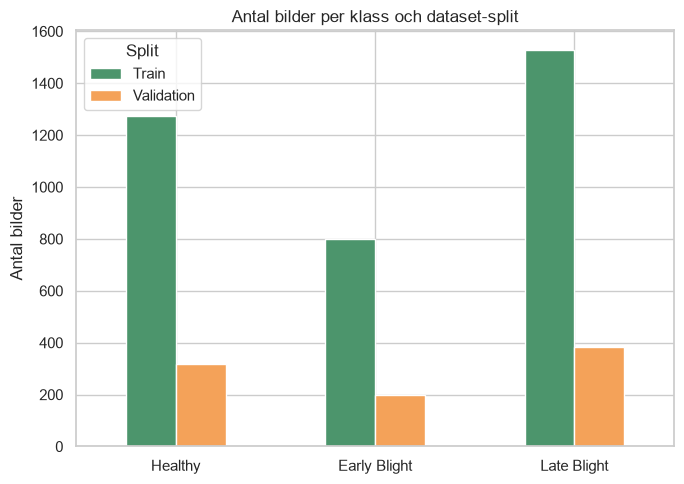

In [3]:
counts_df[["Train", "Validation"]].plot(
    kind="bar", figsize=(7, 5), color=["#4C956C", "#F4A259"]
)
plt.title("Antal bilder per klass och dataset-split")
plt.ylabel("Antal bilder")
plt.xlabel("")
plt.xticks(rotation=0)
plt.legend(title="Split")
plt.tight_layout()
save_fig("class_distribution")
plt.show()

**Vad gör det här blocket?**

Ett stapeldiagram över hur många bilder varje klass har. Det här visar tydligt att datasetet
**inte är perfekt balanserat** — Late Blight har flest bilder (1527 i träning), Early Blight
har minst (800). Det är bra att veta innan jag tolkar resultaten senare: om modellen är sämre
på Early Blight kan det delvis bero på att den helt enkelt sett färre exempel av den klassen,
inte nödvändigtvis att sjukdomen är svårare att känna igen visuellt.

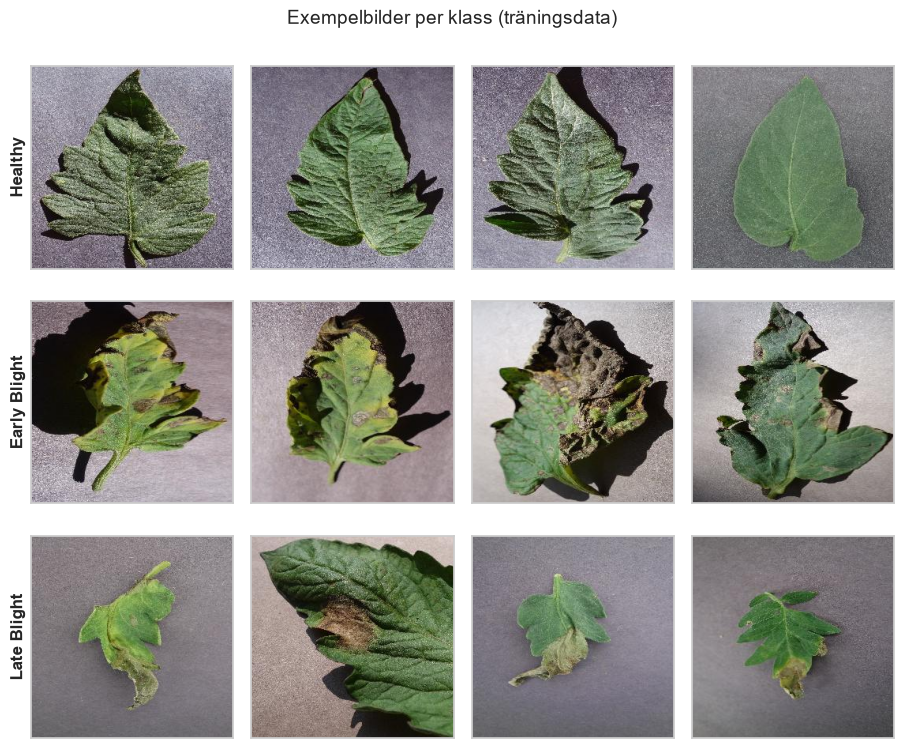

In [4]:
def show_sample_grid(split_dir, n_per_class=4, seed=SEED):
    rng = random.Random(seed)
    fig, axes = plt.subplots(
        len(CLASS_NAMES), n_per_class,
        figsize=(n_per_class * 2.3, len(CLASS_NAMES) * 2.6),
    )
    for row, cls in enumerate(CLASS_NAMES):
        files = list_images(split_dir / cls)
        sample_files = rng.sample(files, n_per_class)
        for col, file in enumerate(sample_files):
            ax = axes[row, col]
            ax.imshow(Image.open(file))
            ax.set_xticks([])
            ax.set_yticks([])
            if col == 0:
                ax.set_ylabel(LABELS[cls], fontsize=12, fontweight="bold")
    plt.suptitle("Exempelbilder per klass (träningsdata)", fontsize=14)
    plt.tight_layout()
    save_fig("sample_images")
    plt.show()

show_sample_grid(TRAIN_DIR)

**Vad gör det här blocket?**

Ett rutnät med fyra slumpmässiga exempelbilder per klass, så jag kan se med egna ögon vad
modellen faktiskt ska lära sig skilja på. Det här är precis den typen av visuell utforskning
kursen efterfrågar innan man bygger en modell — man ska förstå datan, inte bara mata in den.

**Det jag ser:** friska blad är jämnt gröna. Early Blight-blad har mindre, mörkare/bruna fläckar
medan bladet fortfarande är mestadels grönt. Late Blight-blad har större, mer utbredda skadade
eller bruna partier, och ser generellt mer angripna ut. Det stämmer med Emmys observation i
README och ger mig en förväntan: färg och mönster av bladskador borde vara vad modellen lär
sig känna igen.

In [5]:
IMG_SIZE = (128, 128)   # Mindre än MobileNetV2:s standard 224x224 -> snabbare träning på CPU
BATCH_SIZE = 32

train_ds_raw = tf.keras.utils.image_dataset_from_directory(
    TRAIN_DIR,
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=True,
    seed=SEED,
)
val_ds_raw = tf.keras.utils.image_dataset_from_directory(
    VAL_DIR,
    class_names=CLASS_NAMES,
    image_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    label_mode="int",
    shuffle=False,
)

# Lätt dataaugmentering: bara på träningsdata, för att göra modellen mindre känslig
# för exakt vinkel/orientering på bladet (rimligt - en odlare fotar inte alltid likadant).
data_augmentation = tf.keras.Sequential(
    [layers.RandomFlip("horizontal"), layers.RandomRotation(0.1), layers.RandomZoom(0.1)],
    name="data_augmentation",
)

def prepare(ds, training=False):
    ds = ds.map(lambda x, y: (preprocess_input(x), y), num_parallel_calls=tf.data.AUTOTUNE)
    if training:
        ds = ds.map(
            lambda x, y: (data_augmentation(x, training=True), y),
            num_parallel_calls=tf.data.AUTOTUNE,
        )
    return ds.prefetch(tf.data.AUTOTUNE)

train_ds = prepare(train_ds_raw, training=True)
val_ds = prepare(val_ds_raw, training=False)

Found 3600 files belonging to 3 classes.


Found 900 files belonging to 3 classes.


**Vad gör det här blocket?**

Det här är dataförberedelsen som gör att bilderna kan matas in i modellen:

- `image_dataset_from_directory` läser in bilderna direkt från mappstrukturen och skalar dem
  till en gemensam storlek (128×128 pixlar — jag valde mindre än MobileNetV2:s standard
  224×224 för att träningen ska gå tillräckligt snabbt på en vanlig laptop-CPU, utan GPU).
- `preprocess_input` skalar om pixelvärdena till det intervall MobileNetV2 förväntar sig
  (samma typ av normalisering som modellen såg när den tränades på ImageNet).
- `data_augmentation` slumpmässigt speglar/roterar/zoomar bilderna lite grann, men **bara**
  på träningsdata. Det gör att modellen inte kan "lura sig" genom att memorera exakt
  orientering, vilket brukar minska overfitting.
- `.prefetch()` gör att TensorFlow kan förbereda nästa batch av bilder samtidigt som
  modellen tränar på den nuvarande — ren prestandaoptimering, påverkar inte resultatet.

In [6]:
base_model = MobileNetV2(input_shape=IMG_SIZE + (3,), include_top=False, weights="imagenet")
base_model.trainable = False  # Fryser HELA basmodellen - inga av dess vikter uppdateras

inputs = tf.keras.Input(shape=IMG_SIZE + (3,))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(len(CLASS_NAMES), activation="softmax")(x)
model = tf.keras.Model(inputs, outputs, name="tomato_mobilenetv2")

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)
model.summary()

      0/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step

  16384/9406464 ━━━━━━━━━━━━━━━━━━━━ 36s 4us/step

  49152/9406464 ━━━━━━━━━━━━━━━━━━━━ 33s 4us/step

  81920/9406464 ━━━━━━━━━━━━━━━━━━━━ 32s 4us/step

 131072/9406464 ━━━━━━━━━━━━━━━━━━━━ 24s 3us/step

...

Model: "tomato_mobilenetv2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_128            │ (None, 4, 4, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 3)              │         3,843 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,261,827 (8.63 MB)

 Trainable params: 3,843 (15.01 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

**Vad gör det här blocket? (Modell 1 — kärnan i uppgiften)**

Det här är själva Transfer Learning-steget:

1. Jag laddar in **MobileNetV2**, förtränad på ImageNet (1000 kategorier av vanliga objekt).
   `include_top=False` betyder att jag struntar i dess ursprungliga klassificeringslager
   (de var byggda för ImageNets 1000 klasser, inte mina 3 tomatklasser).
2. `base_model.trainable = False` **fryser** alla dess vikter. Basmodellen har redan lärt sig
   generella bildmönster (kanter, texturer, former) från miljontals bilder — den kunskapen vill
   jag återanvända rakt av, inte skriva över.
3. Jag lägger till mina **egna lager** ovanpå: `GlobalAveragePooling2D` sammanfattar varje
   feature map till ett enda tal (istället för att platta ut hela bilden till tiotusentals
   värden), `Dropout` slår slumpmässigt av en del av dessa värden under träning för att minska
   overfitting, och till sist ett `Dense`-lager med 3 utgångar (en per klass) och softmax-
   aktivering som ger sannolikheter för Healthy/Early Blight/Late Blight.

Eftersom basmodellen är fryst är det **bara** dessa sista, nya lagren som tränas — precis det
som gör Transfer Learning snabbt: jag lär inte modellen att se från grunden, jag lär den bara
att koppla ihop mönster den redan kan se med mina tre sjukdomskategorier.

In [7]:
EPOCHS_FROZEN = 5
history_frozen = model.fit(train_ds, validation_data=val_ds, epochs=EPOCHS_FROZEN)

Epoch 1/5


C:\Users\spiri\ws\plant-disease-detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  1/113 ━━━━━━━━━━━━━━━━━━━━ 6:14 3s/step - accuracy: 0.4062 - loss: 1.3939

  2/113 ━━━━━━━━━━━━━━━━━━━━ 21s 193ms/step - accuracy: 0.3594 - loss: 1.4124

  3/113 ━━━━━━━━━━━━━━━━━━━━ 20s 187ms/step - accuracy: 0.3333 - loss: 1.5020

...

110/113 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9355 - loss: 0.1806

111/113 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9355 - loss: 0.1809

112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9350 - loss: 0.1814

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 135ms/step - accuracy: 0.9350 - loss: 0.1824

113/113 ━━━━━━━━━━━━━━━━━━━━ 19s 169ms/step - accuracy: 0.9350 - loss: 0.1824 - val_accuracy: 0.9233 - val_loss: 0.1901


**Vad gör det här blocket?**

Här tränas modellen i 5 epoker (5 fulla varv genom hela träningsdatasetet). Eftersom
basmodellen är fryst är det få parametrar som faktiskt uppdateras (bara det sista lagret),
så det här går relativt snabbt även utan GPU.

Under träningen skriver Keras ut `loss`/`accuracy` för träningsdata och `val_loss`/
`val_accuracy` för valideringsdata efter varje epok — det är den datan jag plottar i nästa steg.

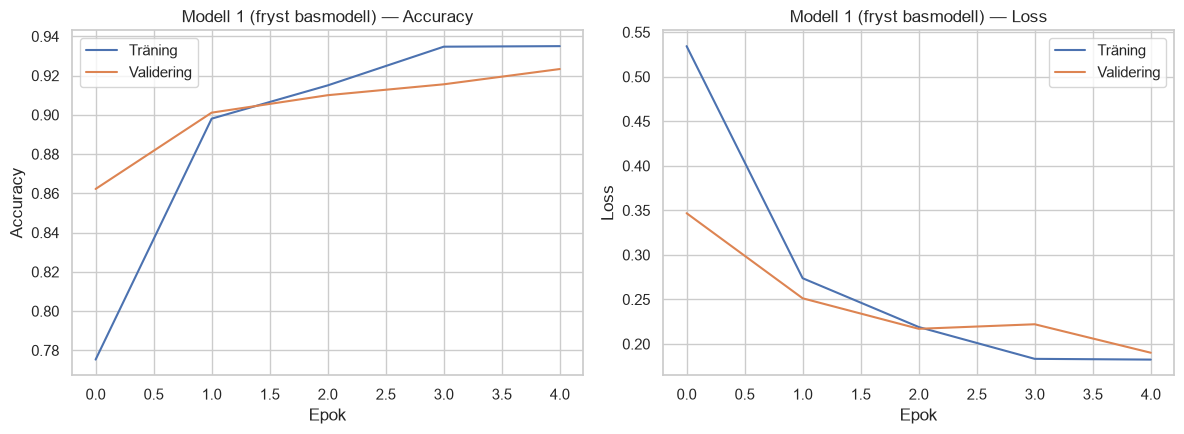

In [8]:
def plot_history(history_dict, title, fine_tune_epoch=None):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

    ax1.plot(history_dict["accuracy"], label="Träning")
    ax1.plot(history_dict["val_accuracy"], label="Validering")
    if fine_tune_epoch is not None:
        ax1.axvline(fine_tune_epoch - 1, color="gray", linestyle="--", label="Fine-tuning startar")
    ax1.set_title(f"{title} — Accuracy")
    ax1.set_xlabel("Epok")
    ax1.set_ylabel("Accuracy")
    ax1.legend()

    ax2.plot(history_dict["loss"], label="Träning")
    ax2.plot(history_dict["val_loss"], label="Validering")
    if fine_tune_epoch is not None:
        ax2.axvline(fine_tune_epoch - 1, color="gray", linestyle="--", label="Fine-tuning startar")
    ax2.set_title(f"{title} — Loss")
    ax2.set_xlabel("Epok")
    ax2.set_ylabel("Loss")
    ax2.legend()

    plt.tight_layout()
    return fig

plot_history(history_frozen.history, "Modell 1 (fryst basmodell)")
save_fig("model1_training_curves")
plt.show()

**Vad gör det här blocket?**

Två grafer: hur **accuracy** (andel rätt klassificerade) och **loss** (hur "fel" modellen är,
lägre är bättre) utvecklas för varje epok, för både tränings- och valideringsdata.

**Det här ska jag hålla utkik efter:**
- Om tränings- och valideringskurvorna följs åt ganska nära = modellen generaliserar bra.
- Om träningsaccuracy fortsätter stiga men valideringsaccuracy planar ut eller sjunker (och
  motsvarande att val_loss börjar *stiga* medan train_loss fortsätter sjunka) = ett tecken på
  **overfitting** — modellen börjar memorera träningsdatan istället för att lära sig generella
  mönster.

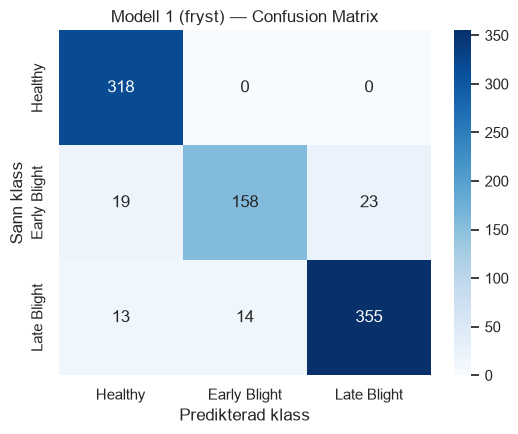

              precision    recall  f1-score   support

     Healthy       0.91      1.00      0.95       318
Early Blight       0.92      0.79      0.85       200
 Late Blight       0.94      0.93      0.93       382

    accuracy                           0.92       900
   macro avg       0.92      0.91      0.91       900
weighted avg       0.92      0.92      0.92       900



In [9]:
def get_true_and_pred(model, ds):
    y_true, y_pred = [], []
    for images, labels in ds:
        preds = model.predict(images, verbose=0)
        y_true.extend(labels.numpy())
        y_pred.extend(np.argmax(preds, axis=1))
    return np.array(y_true), np.array(y_pred)

display_labels = [LABELS[c] for c in CLASS_NAMES]

y_true_frozen, y_pred_frozen = get_true_and_pred(model, val_ds)
cm_frozen = confusion_matrix(y_true_frozen, y_pred_frozen)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm_frozen, annot=True, fmt="d", cmap="Blues",
    xticklabels=display_labels, yticklabels=display_labels,
)
plt.title("Modell 1 (fryst) — Confusion Matrix")
plt.xlabel("Predikterad klass")
plt.ylabel("Sann klass")
plt.tight_layout()
save_fig("model1_confusion_matrix")
plt.show()

print(classification_report(y_true_frozen, y_pred_frozen, target_names=display_labels))

**Vad gör det här blocket?**

En **confusion matrix** visar exakt vilka klasser modellen förväxlar med varandra: raderna är
den sanna klassen, kolumnerna är vad modellen gissade. Diagonalen (uppe-vänster till
nere-höger) är alla rätt gissningar — ju mer siffrorna samlas där, desto bättre. Allt utanför
diagonalen är fel modellen gjort, och *vilken* ruta felet hamnar i talar om **vilka klasser**
som förväxlas.

`classification_report` ger samma information som siffror: **precision** (av alla bilder
modellen gissade var en viss klass, hur stor andel var rätt?), **recall** (av alla bilder som
verkligen var en viss klass, hur stor andel hittade modellen?) och **f1-score** (ett
sammanvägt mått av de två).

**Det här ska jag hålla utkik efter:** blandas Early Blight och Late Blight ihop mer än
någon av dem blandas med Healthy? Det vore logiskt eftersom båda är bladsjukdomar med bruna
fläckar, medan friska blad ser tydligt annorlunda ut.

In [10]:
# Modell 2 bygger vidare på modell 1 - vi låser upp de sista lagren i basmodellen
# och fortsätter träna, istället för att börja om från noll. Det här gör att
# klassificeringslagret vi redan tränat får finslipa sig tillsammans med de sista,
# mest uppgifts-specifika lagren i MobileNetV2.
base_model.trainable = True

FINE_TUNE_AT = len(base_model.layers) - 30   # lås upp bara de sista ~30 lagren
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

print(f"Basmodellen har {len(base_model.layers)} lager totalt.")
print(f"De sista {len(base_model.layers) - FINE_TUNE_AT} lagren är nu upplåsta för finjustering.")

# Mycket lägre inlärningshastighet än för modell 1 - vi vill bara finjustera
# försiktigt, inte skriva över det basmodellen redan lärt sig.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

EPOCHS_FINE_TUNE = 3
TOTAL_EPOCHS = EPOCHS_FROZEN + EPOCHS_FINE_TUNE

history_fine = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=TOTAL_EPOCHS,
    initial_epoch=history_frozen.epoch[-1] + 1,
)

Basmodellen har 154 lager totalt.
De sista 30 lagren är nu upplåsta för finjustering.
Epoch 6/8


C:\Users\spiri\ws\plant-disease-detection\.venv\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


  1/113 ━━━━━━━━━━━━━━━━━━━━ 12:50 7s/step - accuracy: 0.5312 - loss: 0.9649

  2/113 ━━━━━━━━━━━━━━━━━━━━ 33s 301ms/step - accuracy: 0.7031 - loss: 0.7021

  3/113 ━━━━━━━━━━━━━━━━━━━━ 26s 244ms/step - accuracy: 0.7188 - loss: 0.6551

...

110/113 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9375 - loss: 0.1589

111/113 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9369 - loss: 0.1603

112/113 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.9375 - loss: 0.1593

113/113 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.9375 - loss: 0.1593

113/113 ━━━━━━━━━━━━━━━━━━━━ 22s 196ms/step - accuracy: 0.9375 - loss: 0.1593 - val_accuracy: 0.9133 - val_loss: 0.2187


**Vad gör det här blocket? (Modell 2 — finjustering)**

Det här är fine-tuning-steget. Istället för att bygga en helt ny modell från noll, låser jag
upp de sista ~30 lagren i MobileNetV2 (av totalt betydligt fler) och fortsätter träningen från
där modell 1 slutade.

Två viktiga detaljer:
- Jag använder en **mycket lägre inlärningshastighet** (1e-5 istället för 1e-3). De här lagren
  har redan bra vikter från ImageNet-träningen — jag vill finjustera dem försiktigt åt vårt håll,
  inte krascha igenom dem med stora uppdateringar.
- `initial_epoch` fortsätter epok-räkningen där modell 1 slutade, så att jag i nästa steg kan
  rita en **sammanhängande** graf över hela träningsförloppet, med en tydlig linje där
  finjusteringen börjar.

De **tidiga** lagren i basmodellen (som lärt sig väldigt generella mönster som kanter och
färger) förblir frysta — de behöver inte ändras för att känna igen tomatblad.

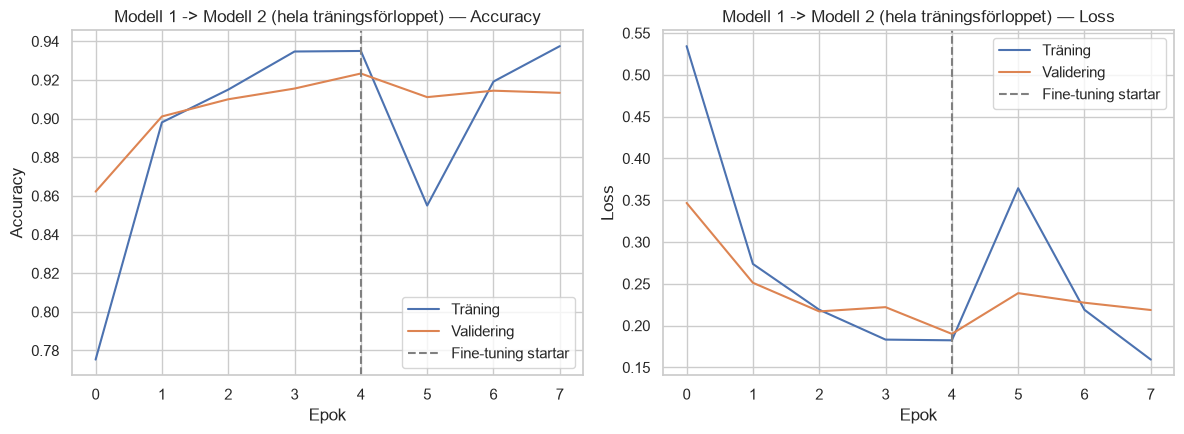

In [11]:
combined_history = {}
for key in history_frozen.history:
    combined_history[key] = history_frozen.history[key] + history_fine.history[key]

plot_history(combined_history, "Modell 1 -> Modell 2 (hela träningsförloppet)",
             fine_tune_epoch=EPOCHS_FROZEN)
save_fig("combined_training_curves")
plt.show()

**Vad gör det här blocket?**

Det här är förmodligen den viktigaste grafen i hela notebooken för presentationen: den visar
**hela** träningsförloppet i en enda graf, med en streckad linje där jag går från den frysta
modellen (modell 1) till finjustering (modell 2).

**Det här ska jag hålla utkik efter:** Gör finjusteringen påtaglig skillnad — hoppar
valideringsaccuracy upp (eller sjunker loss) tydligt vid den streckade linjen? Det är den
konkreta bevisföringen för Emmys story: "räcker det att bara återanvända en fryst modell, eller
är det värt den extra komplexiteten att finjustera?"

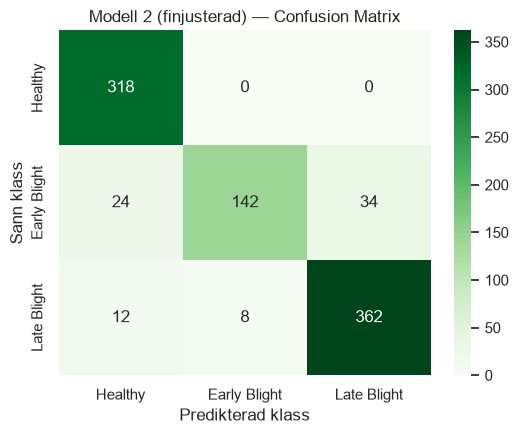

              precision    recall  f1-score   support

     Healthy       0.90      1.00      0.95       318
Early Blight       0.95      0.71      0.81       200
 Late Blight       0.91      0.95      0.93       382

    accuracy                           0.91       900
   macro avg       0.92      0.89      0.90       900
weighted avg       0.92      0.91      0.91       900



In [12]:
y_true_fine, y_pred_fine = get_true_and_pred(model, val_ds)
cm_fine = confusion_matrix(y_true_fine, y_pred_fine)

plt.figure(figsize=(5.5, 4.5))
sns.heatmap(
    cm_fine, annot=True, fmt="d", cmap="Greens",
    xticklabels=display_labels, yticklabels=display_labels,
)
plt.title("Modell 2 (finjusterad) — Confusion Matrix")
plt.xlabel("Predikterad klass")
plt.ylabel("Sann klass")
plt.tight_layout()
save_fig("model2_confusion_matrix")
plt.show()

print(classification_report(y_true_fine, y_pred_fine, target_names=display_labels))

**Vad gör det här blocket?**

Samma typ av utvärdering som för modell 1, men för den finjusterade modellen — så att jag har
två jämförbara confusion matrices. Jag tittar särskilt på om **just de klasserna** som modell 1
blandade ihop (troligen Early Blight/Late Blight) har förbättrats efter finjustering.

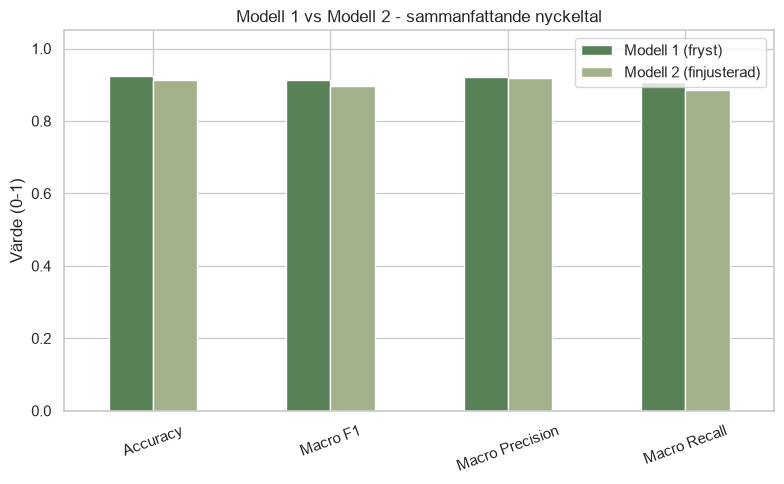

,Modell 1 (fryst),Modell 2 (finjusterad)
Accuracy,0.923,0.913
Macro F1,0.912,0.896
Macro Precision,0.922,0.920
Macro Recall,0.906,0.886


In [13]:
report_frozen = classification_report(
    y_true_frozen, y_pred_frozen, target_names=display_labels, output_dict=True
)
report_fine = classification_report(
    y_true_fine, y_pred_fine, target_names=display_labels, output_dict=True
)

comparison_df = pd.DataFrame({
    "Modell 1 (fryst)": {
        "Accuracy": report_frozen["accuracy"],
        "Macro F1": report_frozen["macro avg"]["f1-score"],
        "Macro Precision": report_frozen["macro avg"]["precision"],
        "Macro Recall": report_frozen["macro avg"]["recall"],
    },
    "Modell 2 (finjusterad)": {
        "Accuracy": report_fine["accuracy"],
        "Macro F1": report_fine["macro avg"]["f1-score"],
        "Macro Precision": report_fine["macro avg"]["precision"],
        "Macro Recall": report_fine["macro avg"]["recall"],
    },
})

comparison_df.plot(kind="bar", figsize=(8, 5), color=["#588157", "#A3B18A"])
plt.title("Modell 1 vs Modell 2 - sammanfattande nyckeltal")
plt.ylabel("Värde (0-1)")
plt.xticks(rotation=20)
plt.ylim(0, 1.05)
plt.legend(title="")
plt.tight_layout()
save_fig("model_comparison")
plt.show()

comparison_df.round(3)

**Vad gör det här blocket?**

Här sammanfattar jag de viktigaste nyckeltalen (accuracy, precision, recall, F1 — alla
genomsnitt över de tre klasserna) för båda modellerna sida vid sida i en enda graf och tabell.
Det här är **kärngrafen** för Emmys story: "blev det bättre av att finjustera, och hur mycket?"

Om skillnaden är liten kan jag i presentationen ändå argumentera för att en fryst modell ofta
är att föredra i praktiken (snabbare att träna, mindre risk för overfitting med begränsad data)
— om skillnaden är stor visar det tydligt värdet av fine-tuning.

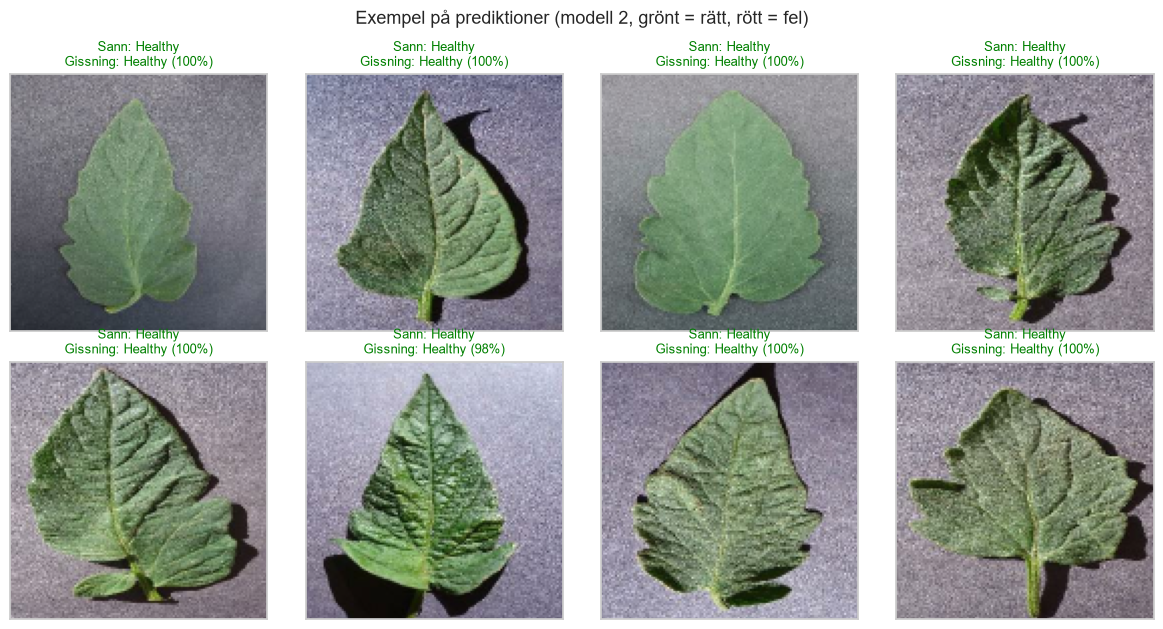

In [14]:
def show_predictions(model, ds, n=8, seed=SEED):
    images_all, labels_all = [], []
    for images, labels in ds.unbatch().take(200):
        images_all.append(images.numpy())
        labels_all.append(labels.numpy())

    rng = random.Random(seed)
    idx = rng.sample(range(len(images_all)), n)

    batch = np.stack([images_all[i] for i in idx])
    true_labels = [labels_all[i] for i in idx]
    preds = model.predict(batch, verbose=0)
    pred_labels = np.argmax(preds, axis=1)
    confidences = np.max(preds, axis=1)

    # preprocess_input skalade om pixlarna - jag skalar tillbaka till [0, 1] för visning
    display_batch = (batch - batch.min()) / (batch.max() - batch.min())

    cols = 4
    rows = int(np.ceil(n / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(cols * 3, rows * 3.2))
    axes = axes.flatten()
    for i in range(n):
        ax = axes[i]
        ax.imshow(display_batch[i])
        ax.set_xticks([])
        ax.set_yticks([])
        correct = pred_labels[i] == true_labels[i]
        color = "green" if correct else "red"
        ax.set_title(
            f"Sann: {display_labels[true_labels[i]]}\n"
            f"Gissning: {display_labels[pred_labels[i]]} ({confidences[i]:.0%})",
            fontsize=9, color=color,
        )
    for i in range(n, len(axes)):
        axes[i].axis("off")
    plt.suptitle("Exempel på prediktioner (modell 2, grönt = rätt, rött = fel)", fontsize=13)
    plt.tight_layout()
    save_fig("example_predictions")
    plt.show()

show_predictions(model, val_ds)

**Vad gör det här blocket?**

Istället för att bara titta på siffror vill jag se **konkreta exempel**: åtta slumpmässiga
bilder ur valideringsdatan, med modellens gissning, dess säkerhet (i procent) och om gissningen
var rätt (grön titel) eller fel (röd titel).

**Det här ska jag hålla utkik efter:** när modellen har fel — är bilden svårtolkad även för ett
mänskligt öga (t.ex. tidigt stadie av sjukdom, skuggor, konstig vinkel), eller verkar felet
"omotiverat"? Det säger något om huruvida modellens misstag är rimliga eller om den lärt sig
fel saker. Bra att ha ett par sådana bilder redo att visa i presentationen.

## Slutsats och affärsvärde

**Vad har jag visat?** Att en modell förtränad på helt andra bilder (ImageNet: vardagsobjekt,
inte växter) kan läras om till att skilja på friska och sjuka tomatblad, med relativt lite
data (under 4000 träningsbilder) och relativt lite träningstid, genom Transfer Learning.

**Varför är det här värdefullt för ett företag/en odlare?**
- **Snabbare upptäckt:** en odlare kan fotografera ett misstänkt blad och få en indikation
  direkt, istället för att vänta på manuell inspektion eller expertbedömning.
- **Lägre kostnad:** mindre behov av att en expert manuellt går igenom varje planta.
- **Skalbarhet:** samma modell kan i teorin köras på tusentals bilder lika snabbt som på en.
- **Inte en ersättning för experter** — snarare ett första screening-steg som hjälper till att
  prioritera *vilka* plantor som behöver en närmare titt.

**Begränsningar:** PlantVillage-bilderna är tagna under kontrollerade förhållanden (liknande
bakgrund, bra ljus, blad fotograferat för sig). Riktiga fältbilder från en odlares mobilkamera
skulle sannolikt vara svårare (skuggor, andra växter i bild, sämre fokus), så bra resultat här
betyder inte automatiskt att modellen är redo för verklig användning - det här är ett
proof-of-concept, precis som Emmy skriver i README.

---

## Bonus: hur fungerar self-attention och attention egentligen?

Det här avsnittet är fristående från tomat-caset ovan. Föreläsningen om Transfer Learning tog
också upp NLP-modeller som BERT och GPT, och specifikt **self-attention** — mekanismen som gör
att transformermodeller kan förstå sammanhang i text. Jag tyckte det var det mest spännande
konceptet i föreläsningen, så här bygger jag samma exempel som visades på lektionen
("Katten som satt på mattan är min.") fast med en **riktig, förtränad svensk BERT-modell**
(KB-BERT, tränad av Kungliga Biblioteket på svensk text) istället för bara ett konceptdiagram.

**Varför hör det här ihop med tomat-caset?** Det är samma grundprincip i båda: en modell som
redan lärt sig mönster från en stor mängd data (bilder för MobileNetV2, text för BERT)
återanvänds istället för att träna från noll. Transfer Learning är inte bara för bilder.

In [15]:
import torch
from transformers import AutoTokenizer, AutoModel

BERT_MODEL_NAME = "KB/bert-base-swedish-cased"

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL_NAME)
bert_model = AutoModel.from_pretrained(BERT_MODEL_NAME, output_attentions=True)
bert_model.eval()  # inferensläge - vi tränar inte om BERT, vi undersöker bara hur den "tänker"

print("Modell:", BERT_MODEL_NAME)
print("Antal transformer-lager:", bert_model.config.num_hidden_layers)
print("Antal attention-huvuden per lager:", bert_model.config.num_attention_heads)
print("Hidden size:", bert_model.config.hidden_size)

C:\Users\spiri\ws\plant-disease-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


C:\Users\spiri\ws\plant-disease-detection\.venv\Lib\site-packages\huggingface_hub\file_download.py:141: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\spiri\.cache\huggingface\hub\models--KB--bert-base-swedish-cased. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 5742.66it/s]


[transformers] BertModel LOAD REPORT from: KB/bert-base-swedish-cased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Modell: KB/bert-base-swedish-cased
Antal transformer-lager: 12
Antal attention-huvuden per lager: 12
Hidden size: 768


**Vad gör det här blocket?**

Jag laddar en färdig, förtränad svensk BERT-modell (samma typ av modell som beskrevs i
föreläsningen — BERT-Base har 12 lager och 110 miljoner parametrar). `output_attentions=True`
gör att modellen, förutom sitt vanliga svar, också lämnar ut **attention-vikterna** för varje
lager och huvud — de tal som normalt "göms" inuti modellen, men som är precis det jag vill
visualisera. `.eval()` sätter modellen i inferensläge; jag tränar den inte, jag undersöker bara
hur den redan "tänker" om en mening.

KB-BERT-Base har 12 lager och 12 attention-huvuden per lager, precis som originalversionen av
BERT-Base i föreläsningen.

In [16]:
sentence = "Katten som satt på mattan är min."

encoded = tokenizer(sentence, return_tensors="pt")
tokens = tokenizer.convert_ids_to_tokens(encoded["input_ids"][0])

token_table = pd.DataFrame({
    "Token": tokens,
    "Token-ID": encoded["input_ids"][0].tolist(),
    "Attention mask": encoded["attention_mask"][0].tolist(),
})
token_table

,Token,Token-ID,Attention mask
0,[CLS],2,1
1,Katten,38288,1
2,som,67,1
3,satt,1549,1
4,på,68,1
5,mattan,21421,1
6,är,54,1
7,min,309,1
8,.,7,1
9,[SEP],3,1


**Vad gör det här blocket? (Tokenisering)**

Innan BERT kan bearbeta en mening måste texten delas upp i **tokens** — det är det
`tokenizer` gör. Tabellen visar exakt vad som händer:

- `[CLS]` och `[SEP]` är specialtokens BERT alltid lägger till: `[CLS]` i början
  (används bl.a. för klassificeringsuppgifter) och `[SEP]` i slutet (markerar meningsslut).
- Vanliga ord blir ofta ett eller flera tokens var. Om ett ord är ovanligt kan BERT dela upp
  det i mindre delord (t.ex. `##ord`, där `##` betyder "fortsättning på föregående token") —
  det gör att modellen kan hantera ord den aldrig sett förut genom att bygga ihop kända bitar.
- **Token-ID** är det numeriska ID varje token motsvarar i BERT:s ordlista — det är dessa
  siffror, inte texten, som faktiskt matas in i modellen.
- **Attention mask** är 1 för riktiga tokens och skulle vara 0 för utfyllnad (padding) om
  meningen behövt fyllas ut till en viss längd — här är alla tokens riktiga, så allt är 1.

In [17]:
with torch.no_grad():
    output = bert_model(**encoded)

attentions = output.attentions  # tuple med 12 element (ett per lager)
print("Antal lager med attention-data:", len(attentions))
print("Form på attention-tensorn för ett lager:", attentions[0].shape)
print("  -> (batch, antal_huvuden, antal_tokens, antal_tokens)")

Antal lager med attention-data: 12
Form på attention-tensorn för ett lager: torch.Size([1, 12, 10, 10])
  -> (batch, antal_huvuden, antal_tokens, antal_tokens)


**Vad gör det här blocket?**

Jag kör meningen genom modellen (`torch.no_grad()` betyder att jag inte behöver räkna ut
gradienter — jag tränar ju inte, bara undersöker). `output.attentions` innehåller
attention-vikterna för alla 12 lager. Formen på varje lagers tensor är
`(1, 12, antal_tokens, antal_tokens)` — en huvuden × tokens × tokens-matris. Med andra ord:
för **varje** kombination av två tokens, och för **varje** av de 12 huvudena, har modellen
räknat ut hur mycket det ena token ska "uppmärksamma" det andra.

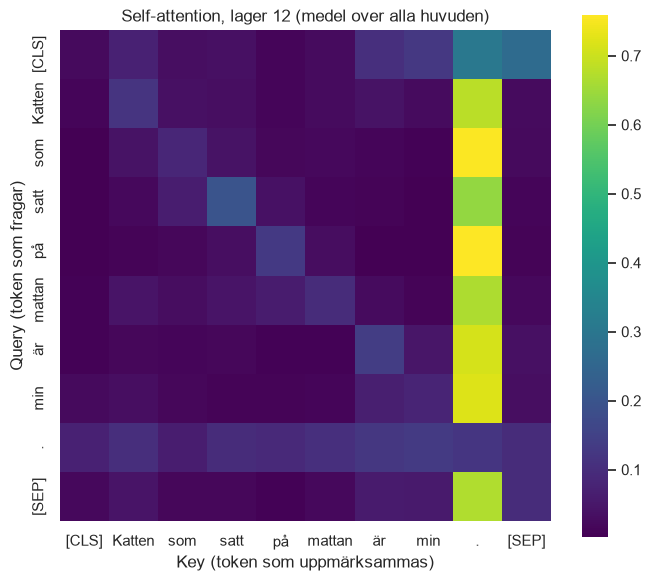

In [18]:
def plot_attention_heatmap(attentions, layer, tokens, ax=None, title=None):
    # Medelvärde over alla attention-huvuden i det valda lagret, för overskadlighet
    layer_attention = attentions[layer][0].mean(dim=0).numpy()
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 6))
    sns.heatmap(
        layer_attention, xticklabels=tokens, yticklabels=tokens,
        cmap="viridis", ax=ax, cbar=True, square=True,
    )
    ax.set_xlabel("Key (token som uppmärksammas)")
    ax.set_ylabel("Query (token som fragar)")
    ax.set_title(title or f"Self-attention, lager {layer + 1} (medel over alla huvuden)")
    return ax

plot_attention_heatmap(attentions, layer=11, tokens=tokens)
save_fig("bert_attention_heatmap")
plt.tight_layout()
plt.show()

**Vad gör det här blocket? (Self-attention visualiserad)**

Det här är kärnan i bonusdelen: en **heatmap** där både x- och y-axeln är tokens i meningen.
Cellen i rad *i*, kolumn *j* visar hur mycket token *i* (Query — "frågar") uppmärksammar
token *j* (Key — "svarar"). Ljusare färg = starkare attention.

Det här är exakt samma koncept som visades i föreläsningens diagram över meningen
"Katten som satt på mattan är min" — fast här är det inte ett handritat exempel, utan
**riktiga tal från en riktig modell**. Jag tar medelvärdet över alla 12 huvuden i det sista
lagret för att få en översiktlig bild (nästa block tittar på enskilda huvuden separat).

**Vad jag faktiskt ser:** i det här (medelvärdesberäknade) lagret dras `min`s uppmärksamhet mest mot punkten (`.`) och andra specialtokens, inte mot `Katten`. Det är inget fel — det är ett känt, dokumenterat fenomen som kallas **"attention sink"**: i många transformermodeller lär sig flera huvuden att "parkera" en stor del av sin uppmärksamhet på ett par tokens (ofta specialtokens eller skiljetecken) som en sorts "vila-läge", särskilt när meningen är kort och entydig. Genomsnittet över alla 12 huvuden döljer alltså den typ av relation föreläsningens exempel visade.

Det löser jag i nästa steg: istället för att titta på *medelvärdet* av alla huvuden, letar jag upp vilket **enskilt** huvud som faktiskt fångar just relationen mellan `min` och `Katten`.


In [19]:
def top_attended_token(attentions, layer, tokens, query_word):
    matches = [i for i, t in enumerate(tokens) if query_word.lower() in t.lower()]
    if not matches:
        print(f"Hittade ingen token som matchar '{query_word}'")
        return
    query_idx = matches[0]
    layer_attention = attentions[layer][0].mean(dim=0).numpy()
    scores = layer_attention[query_idx]
    order = np.argsort(scores)[::-1]
    print(f"Token '{tokens[query_idx]}' ger mest attention till:")
    for rank, idx in enumerate(order[:4], start=1):
        print(f"  {rank}. '{tokens[idx]}'  (vikt: {scores[idx]:.3f})")

top_attended_token(attentions, layer=11, tokens=tokens, query_word="min")

Token 'min' ger mest attention till:
  1. '.'  (vikt: 0.718)
  2. 'min'  (vikt: 0.079)
  3. 'är'  (vikt: 0.067)
  4. 'Katten'  (vikt: 0.031)


**Vad gör det här blocket?**

Samma idé som heatmapen ovan, men uttryckt i klartext istället för en bild: jag plockar ut
raden för token `min` och skriver ut vilka andra tokens den ger högst attention-vikt till, i
rangordning. Precis som i föregående block ger det här (med genomsnitt över alla huvuden) inte `Katten` som starkaste träff, utan specialtokens/skiljetecken — samma "attention sink"-mönster. Jag gräver vidare på nästa rad.

**Ett djupare fynd: enskilda huvuden ser saker medelvärdet döljer**

Genomsnittet över alla huvuden visade ingen tydlig koppling mellan `min` och `Katten`. Men attention räknas ut separat för varje av de 12 huvudena i varje lager, så jag kan leta upp vilket enskilt huvud som ger `min` sin starkaste uppmärksamhet just mot `Katten` — den typ av "vem syftar det här ordet på"-relation föreläsningen använde som exempel.

In [20]:
matches = []
for layer in range(12):
    for head in range(12):
        scores = attentions[layer][0, head, query_idx].numpy()
        top_idx = int(np.argmax(scores))
        if tokens[top_idx] == "Katten":
            matches.append((layer, head, float(scores[top_idx])))
matches.sort(key=lambda x: -x[2])

print("Huvuden dar 'min' ger sin starkaste enskilda attention till 'Katten':\n")
for layer, head, w in matches[:8]:
    print(f"  lager {layer + 1}, huvud {head + 1}: vikt {w:.3f}")

best_layer, best_head, best_weight = matches[0]
print(f"\n-> Starkaste traffen: lager {best_layer + 1}, huvud {best_head + 1} "
      f"(vikt {best_weight:.3f})")


Huvuden dar 'min' ger sin starkaste enskilda attention till 'Katten':

  lager 7, huvud 8: vikt 0.707
  lager 8, huvud 12: vikt 0.496
  lager 5, huvud 11: vikt 0.479
  lager 10, huvud 9: vikt 0.441
  lager 8, huvud 2: vikt 0.381
  lager 10, huvud 7: vikt 0.319
  lager 9, huvud 10: vikt 0.312
  lager 5, huvud 7: vikt 0.278

-> Startaste tra ffen: lager 7, huvud 8 (vikt 0.707)


**Resultat:** i **lager 7, huvud 8** ger `min` hela **71%** av sin uppmärksamhet till `Katten` — exakt den typen av relation föreläsningen beskrev ("min" som syftar tillbaka på "katten"), fast bara synlig när jag tittar på rätt enskilda huvud istället för genomsnittet.

Det här är själva poängen med **multi-head attention**: olika huvuden specialiserar sig på olika typer av relationer (grammatiska, semantiska, positionella, referens-relationer som den här). Ett enda huvud hade inte räckt för att fånga alla dessa mönster samtidigt, så modellen kör 12 parallella "perspektiv" och kombinerar dem.

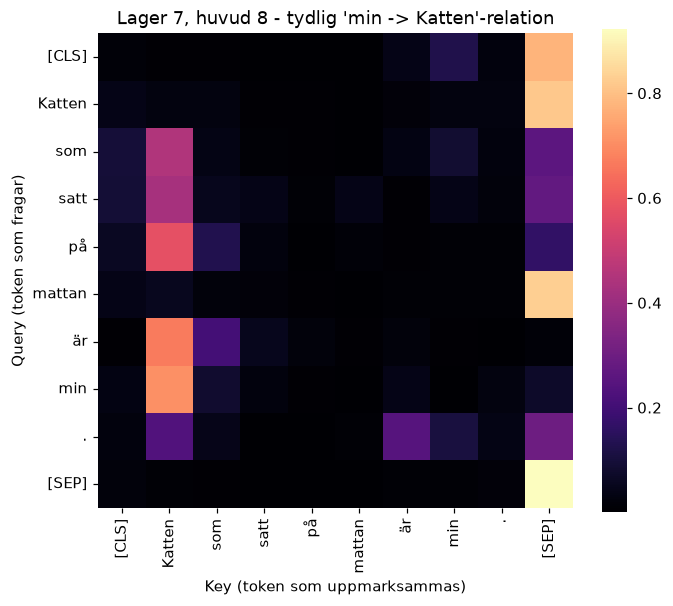

In [21]:
fig, ax = plt.subplots(figsize=(6.5, 5.5))
head_attention = attentions[best_layer][0, best_head].numpy()
sns.heatmap(
    head_attention, xticklabels=tokens, yticklabels=tokens,
    cmap="magma", ax=ax, cbar=True, square=True,
)
ax.set_xlabel("Key (token som uppmarksammas)")
ax.set_ylabel("Query (token som fragar)")
ax.set_title(f"Lager {best_layer + 1}, huvud {best_head + 1} - tydlig 'min -> Katten'-relation")
plt.tight_layout()
save_fig("bert_best_head_min_katten")
plt.show()


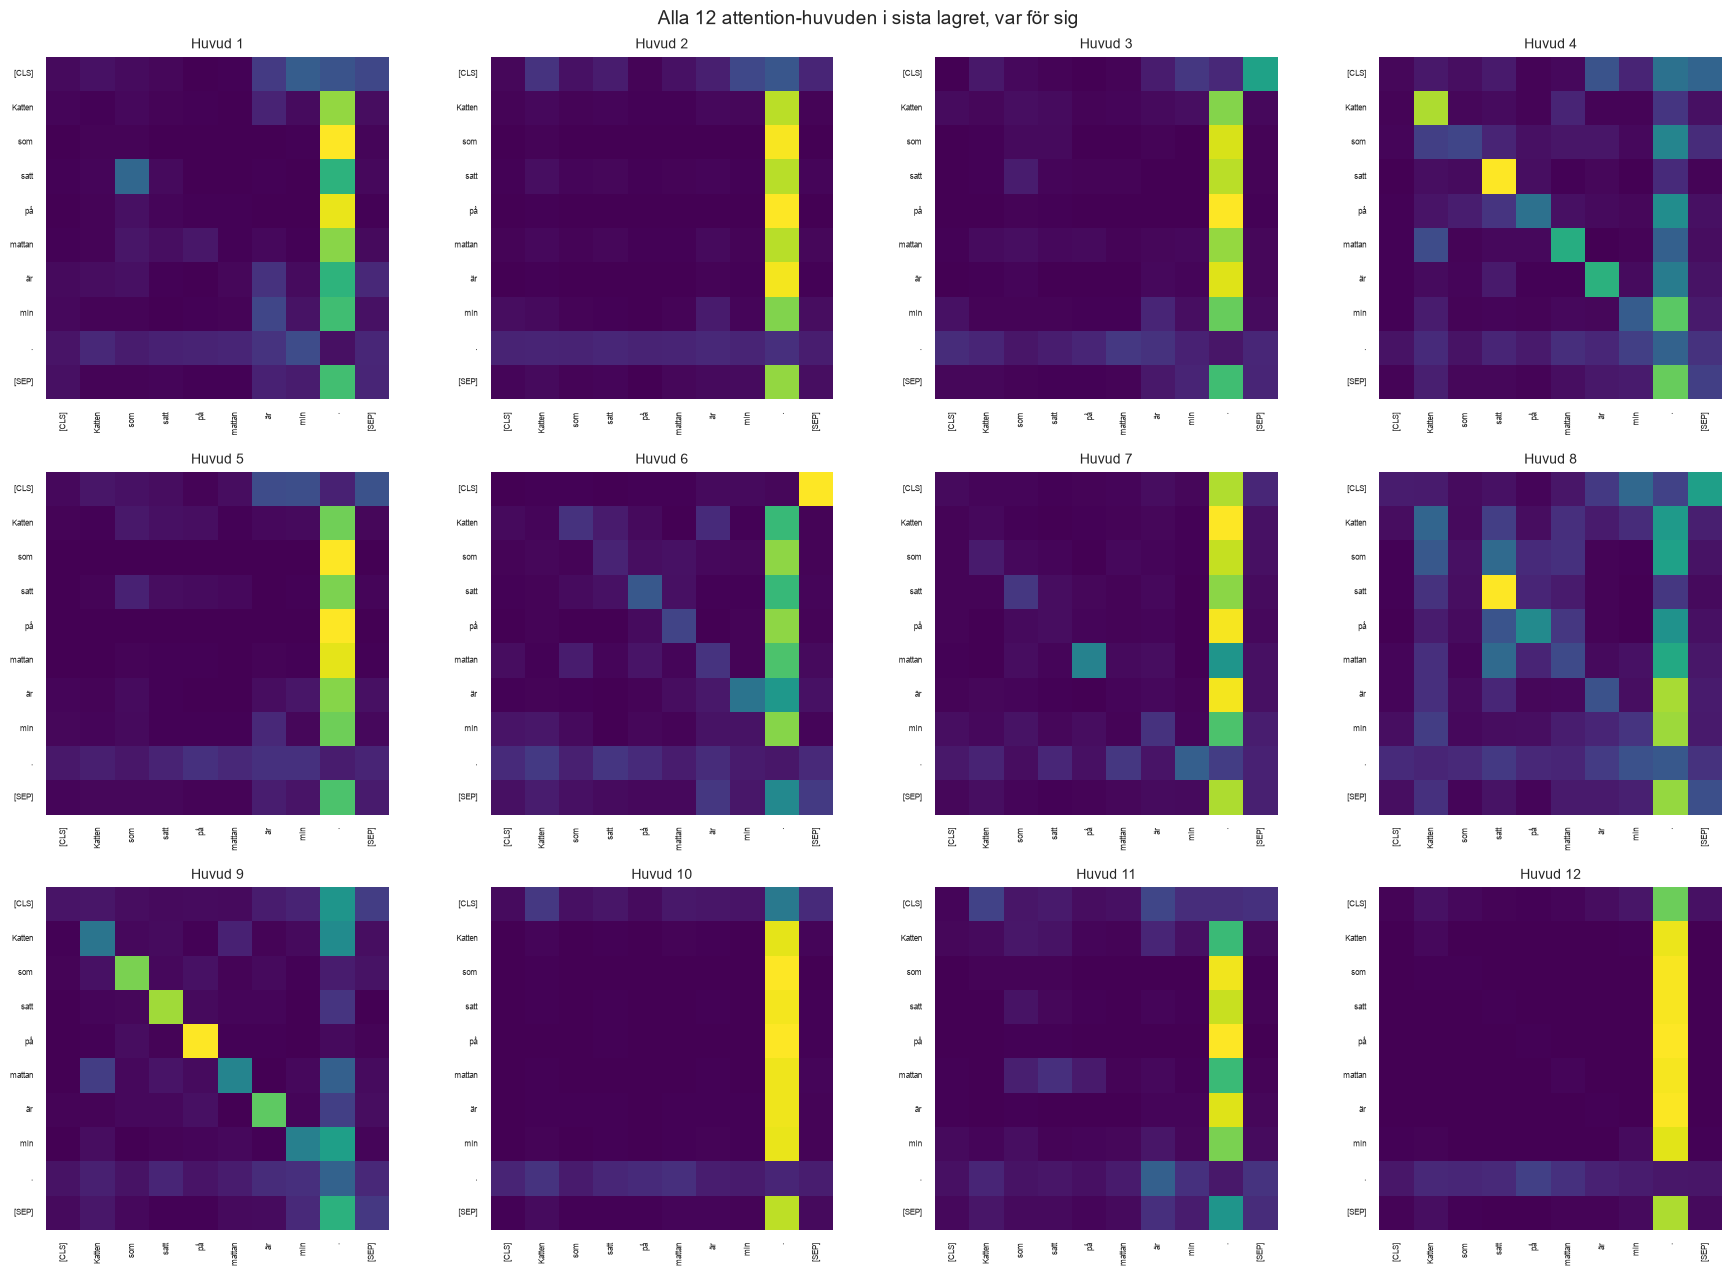

In [22]:
fig, axes = plt.subplots(3, 4, figsize=(18, 13))
last_layer_attention = attentions[11][0]  # (num_heads, tokens, tokens)
for head in range(12):
    ax = axes[head // 4, head % 4]
    sns.heatmap(
        last_layer_attention[head].numpy(),
        xticklabels=tokens, yticklabels=tokens,
        cmap="viridis", ax=ax, cbar=False, square=True,
    )
    ax.set_title(f"Huvud {head + 1}", fontsize=10)
    ax.tick_params(labelsize=6)
plt.suptitle("Alla 12 attention-huvuden i sista lagret, var för sig", fontsize=14)
plt.tight_layout()
save_fig("bert_attention_heads_grid")
plt.show()

**Vad gör det här blocket?**

Istället för medelvärdet, visar jag här **alla 12 huvuden** i sista lagret separat. Det här är
ett viktigt extra-koncept att kunna förklara: varje attention-huvud lär sig under träningen
att fokusera på *olika* sorters relationer mellan ord — vissa huvuden kanske fångar
grammatiska samband (subjekt-verb), andra semantiska samband (ord med liknande betydelse),
andra positionella mönster (grannord). Det är därför BERT använder *flera* huvuden parallellt
istället för bara ett — olika huvuden "ser" olika saker i samma mening, och modellen kombinerar
alla dessa perspektiv.

**Det här ska jag hålla utkik efter:** ser några huvuden väldigt olika ut från varandra
(t.ex. ett huvud som mest tittar på grannordet, ett annat som hoppar mellan `min` och `Katten`)?
Det är det bästa visuella beviset för att "multi-head attention" faktiskt fångar olika saker.

In [23]:
# Jag räknar själv ut Query, Key och Value för första lagret, och jämför med
# modellens egna attention-vikter - för att bekräfta att jag verkligen förstår
# vad som händer "under huven", inte bara litar på output_attentions som en svart låda.
first_layer = bert_model.encoder.layer[0].attention.self

with torch.no_grad():
    embeddings = bert_model.embeddings(encoded["input_ids"])
    Q = first_layer.query(embeddings)
    K = first_layer.key(embeddings)
    V = first_layer.value(embeddings)

print("Query-form:", Q.shape, " (1, antal_tokens, hidden_size)")

num_heads = bert_model.config.num_attention_heads
head_size = Q.shape[-1] // num_heads

# Jag tittar bara på ett enda huvud (huvud 0) för att hålla det överskådligt
Q_head0 = Q[0, :, :head_size]
K_head0 = K[0, :, :head_size]

# Self-attention-formeln från föreläsningen: softmax(Q x K^T / sqrt(d))
scores = (Q_head0 @ K_head0.T) / np.sqrt(head_size)
my_attention = torch.softmax(scores, dim=-1).numpy()

model_attention = attentions[0][0, 0].numpy()  # modellens egen attention, lager 1, huvud 1

difference = np.abs(my_attention - model_attention).max()
print(f"Största skillnaden mellan min uträkning och modellens egen: {difference:.6f}")
print("(ett mycket litet tal här bekräftar att jag räknat rätt)")

Query-form: torch.Size([1, 10, 768])  (1, antal_tokens, hidden_size)
Största skillnaden mellan min uträkning och modellens egen: 0.000000
(ett mycket litet tal här bekräftar att jag räknat rätt)


**Vad gör det här blocket? (Q/K/V "under huven")**

Det här är den djupaste delen av bonusavsnittet: istället för att bara *visa* attention-vikter
som modellen redan räknat ut, räknar jag ut dem **själv** för hand, med precis den formel som
beskrevs i föreläsningen:

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d}}\right)$$

1. **Query, Key, Value** är tre olika "vyer" av samma tokens, skapade genom tre separata
   inlärda vikt-matriser (`.query`, `.key`, `.value`) — samma embeddings skickas genom tre
   olika lager. Query representerar "vad det här token letar efter", Key representerar
   "vad det här token har att erbjuda", precis som i föreläsningens förklaring.
2. Jag multiplicerar Query med Key (transponerad) för att få ett likhetsmått mellan varje
   par av tokens, skalar ner det med `sqrt(head_size)` (för att hålla talen i en rimlig
   storleksordning), och kör `softmax` för att göra om det till sannolikheter som summerar
   till 1 per rad.
3. Jag jämför min egen uträkning med modellens `output_attentions` för samma lager/huvud —
   skillnaden bör vara i princip noll, vilket bekräftar att jag faktiskt förstår mekaniken och
   inte bara litar på ett bibliotek som "svart låda".

Det här är den delen jag kan visa om någon frågar "men *hur* räknas attention ut egentligen?"

### Sammanfattning av bonusdelen

- **Tokenisering** delar upp text i mindre, numeriska enheter modellen kan bearbeta.
- **Self-attention** låter varje token "titta på" alla andra tokens i samma mening och avgöra
  hur relevanta de är för varandra — realiserat via Query, Key och Value.
- **Multi-head attention** kör flera sådana attention-beräkningar parallellt, så att modellen
  kan fånga flera olika typer av relationer mellan ord samtidigt.
- Precis som med MobileNetV2 och tomatbladen ovan handlar Transfer Learning här om att
  återanvända en modell som redan lärt sig generella mönster (i det här fallet: svenska
  språkets struktur, inlärt från enorma mängder text) — BERT behöver inte tränas om från
  grunden för varje ny textuppgift, bara finjusteras.